# SW radiation comparison

In [2]:
# librariies
import xarray as xr
import numpy as np
import pandas as pd

from snobedo.snotel import SnotelLocations
from snobedo.snotel import SnotelLocations, CsvParser

from snobedo.lib.dask_utils import start_cluster, client_ip_and_port

from pathlib import Path, PurePath

import matplotlib.pyplot as plt

import os
import glob

In [3]:
client = start_cluster(4, 24)
client_ip_and_port(client)

/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 37509 instead
  warnings.warn(
2025-06-26 11:31:26,145 - tornado.application - ERROR - Exception in callback functools.partial(<bound method IOLoop._discard_future_result of <tornado.platform.asyncio.AsyncIOMainLoop object at 0x7f58a4a6b740>>, <Task finished name='Task-5823' coro=<SpecCluster._correct_state_internal() done, defined at /uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/distributed/deploy/spec.py:346> exception=RuntimeError('Command exited with non-zero exit code.\nExit code: 1\nCommand:\nsbatch /scratch/local/u1037042/4935410/tmp_tuiepcn.sh\nstdout:\n\nstderr:\nsbatch: error: Batch job submission failed: Invalid qos specification\n\n')>)
Traceback (most recent call la

10.242.76.198:37509


In [3]:
# Directory containing the .cdf files

# # SAIL
# directory_m1 = "/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/sebs_SAIL/M1/*.cdf"
# directory_s3 = "/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/sebs_SAIL/S3/*.cdf"
# m1_sail_list = [np.squeeze(xr.open_dataset(nc)) for nc in sorted(glob.glob(directory_m1))]
# m1_sail = xr.concat(m1_sail_list, dim='time')
# s3_sail_list = [np.squeeze(xr.open_dataset(nc)) for nc in sorted(glob.glob(directory_s3))]
# s3_sail = xr.concat(s3_sail_list, dim='time')

# # SOS
# sos_path = '/uufs/chpc.utah.edu/common/home/u1037042/olson/snow-data/station-data/sos-isfs/hourlyAvg_radiation_uw.nc'
# # sos_single = '/uufs/chpc.utah.edu/common/home/u1037042/olson/snow-data/station-data/sos-isfs/sos_isfs_qc_geo_tiltcor_5min_v20241227/isfs_sos_qc_geo_tiltcor_5min_v2_20230212.nc'
# ds = xr.open_dataset(sos_path)
# print(ds)

# # AMR - QCRAD
# directory_m1_qcrad = "/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/station-data/qcrad1long/*.cdf"
# m1_qcrad_list = [np.squeeze(xr.open_dataset(nc)) for nc in sorted(glob.glob(directory_m1_qcrad))]
# m1_qcrad = xr.concat(m1_qcrad_list, dim='time')

In [17]:
# directory_m1 = "/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/sebs_SAIL/M1/*.cdf"
# m1_sail = xr.open_mfdataset(
#     directory_m1,
#     combine='by_coords',
#     parallel=True,
#     preprocess=lambda ds: ds.squeeze(),
#     chunks={'time': 24} 
# )

# directory_s3 = "/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/sebs_SAIL/S3/*.cdf"
# s3_sail = xr.open_mfdataset(
#     directory_s3,
#     combine='by_coords',
#     parallel=True,
#     preprocess=lambda ds: ds.squeeze(),
#     chunks={'time': 24} 
# )

In [7]:
# from dask.distributed import Client

# client = Client()

# def preprocess(ds):
#     return ds[[
#         'down_short_hemisp',
#         'down_short_diffuse_hemisp',
#         'short_direct_normal',
#         'BestEstimate_down_short_hemisp',
#         'zenith'
#     ]].squeeze()
# directory_m1_qcrad = "/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/station-data/qcrad1long/*.cdf"
# m1_qcrad = xr.open_mfdataset(
#     directory_m1_qcrad,
#     combine='by_coords',
#     parallel=True,
#     preprocess=preprocess,
#     chunks={'time': 24}
# )


In [5]:
from dask.distributed import Client

# 5-6 mins

# start dask
client = Client()

# M1 QCRAD
# /uufs/chpc.utah.edu/common/home/u1037042/olson/snow-data/station-data/qcrad1long
directory_m1_qcrad = "/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/station-data/qcrad1long/*.cdf"
m1_qcrad = xr.open_mfdataset(
    directory_m1_qcrad,
    combine='by_coords',
    parallel=True,
    # preprocess=lambda ds: ds.squeeze(),
    chunks={'time': 24} 
)

# M1 SAIL
directory_m1 = "/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/sebs_SAIL/M1/*.cdf"
m1_sail = xr.open_mfdataset(
    directory_m1,
    combine='by_coords',
    parallel=True,
    # preprocess=lambda ds: ds.squeeze(),
    chunks={'time': 24} 
)

# S3 SAIL
directory_s3 = "/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/sebs_SAIL/S3/*.cdf"
s3_sail = xr.open_mfdataset(
    directory_s3,
    combine='by_coords',
    parallel=True,
    # preprocess=lambda ds: ds.squeeze(),
    chunks={'time': 24} 
)


/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 32905 instead
  warnings.warn(
2025-06-26 11:32:40,613 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:43105' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {'getattr-6227c339-bf03-4f99-9195-2a68605bf143', 'open_dataset-0b65731c-48b9-47bc-99de-35849652be81', 'getattr-e601c02d-2869-4795-9967-a593bb8b834f', 'open_dataset-a0b630da-b788-44b6-b693-b9c8603ac480', 'getattr-c05d67e7-ddf5-468d-a160-6961858da025', 'open_dataset-d607060b-3060-412f-be00-9dcb8aa6b29f', 'getattr-d082aaf6-dfbc-4283-af15-34e6a3988ed5', 'open_dataset-7c1247a5-4b2b-483b-b9b4-6a5a9a5eb291', 'getattr-c03eeeb2-0e25-45d7-89ce-2c4f94b28238', 'open_dataset-ac7160ef-1315-4721-8987-c8a220ceb296', 'open_dataset-852f7559-

RuntimeError: NetCDF: Not a valid ID

In [8]:
m1_qcrad
# down_short_hemisp
# BestEstimate_down_short_hemisp
#
# down_short_diffuse_hemisp
# short_direct_normal
# s3_sail
# m1_sail

NameError: name 'm1_qcrad' is not defined

In [7]:
# SOS
sos_path = '/uufs/chpc.utah.edu/common/home/u1037042/olson/snow-data/station-data/sos-isfs/hourlyAvg_radiation_uw.nc'
# sos_single = '/uufs/chpc.utah.edu/common/home/u1037042/olson/snow-data/station-data/sos-isfs/sos_isfs_qc_geo_tiltcor_5min_v20241227/isfs_sos_qc_geo_tiltcor_5min_v2_20230212.nc'
ds = xr.open_dataset(sos_path)

In [ ]:
# m1_qcrad
# down_short_hemisp
# BestEstimate_down_short_hemisp
#
# down_short_diffuse_hemisp
# short_direct_normal

# Plot the variable over time
# plt.figure(figsize=(14, 5))
# m1_qcrad['down_short_hemisp'].plot(x='time', color='red')
# m1_qcrad['short_direct_normal'].plot(x='time', color='orange')
# m1_qcrad['down_short_diffuse_hemisp'].plot(x='time', color='yellow')

# # Formatting
# plt.title('QCRAD - ARM')
# plt.xlabel('Time')
# plt.ylabel('Irradiance (W/m²)')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [ ]:
# Subset once
# subset = m1_qcrad.sel(time=slice("2021-10-01", "2022-06-30"))

# Resample once
subset_hourly = m1_qcrad.resample(time='1h').mean().persist()

# Access variables
subset_sw_hourly = subset_hourly['down_short_hemisp']
subset_dif_hourly = subset_hourly['down_short_diffuse_hemisp']
subset_dir_hourly = subset_hourly['short_direct_normal']
subset_best_hourly = subset_hourly['BestEstimate_down_short_hemisp']
subset_zenith_hourly = subset_hourly['zenith']


In [8]:
# subset_sw = m1_qcrad['down_short_hemisp'].sel(time=slice("2021-10-01", "2022-06-30")).load()

subset_sw_hourly = m1_qcrad['down_short_hemisp'].sel(time=slice("2021-10-01", "2022-06-30")).resample(time='1h').mean().load()
subset_dif_hourly = m1_qcrad['down_short_diffuse_hemisp'].sel(time=slice("2021-10-01", "2022-06-30")).resample(time='1h').mean().load()
subset_dir_hourly = m1_qcrad['short_direct_normal'].sel(time=slice("2021-10-01", "2022-06-30")).resample(time='1h').mean().load()
subset_best_hourly = m1_qcrad['BestEstimate_down_short_hemisp'].sel(time=slice("2021-10-01", "2022-06-30")).resample(time='1h').mean().load()
# short dir normal - adjust for zenith angle...
subset_zenith_hourly = m1_qcrad['zenith'].sel(time=slice("2021-10-01", "2022-06-30")).resample(time='1h').mean().load()

2025-06-26 11:00:51,410 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Traceback (most recent call last):
  File "/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/asyncio/runners.py", line 118, in run
    return self._loop.run_until_complete(task)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/asyncio/base_events.py", line 687, in run_until_complete
    return future.result()
           ^^^^^^^^^^^^^^^
  File "/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/distributed/nanny.py", line 984, in run
    await worker.finished()
  File "/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/distributed/core.py", line 491, in finished
   

KeyboardInterrupt: 

In [ ]:
m1_sw_hourly_sail = m1_sail['down_short_hemisp'].sel(time=slice("2021-10-01", "2022-06-30")).resample(time='1h').mean().load()


In [10]:
subset_zenith_hourly

<xarray.DataArray 'zenith' (time: 6552)> Size: 26kB
array([ 86.29362 ,  98.20213 , 109.75408 , ...,  33.237373,  44.602707,
        56.229664], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 52kB 2021-10-01 ... 2022-06-30T23:00:00
Attributes:
    long_name:      Solar Zenith Angle
    units:          degree
    comment:        Calculated using solarposition() function, by Nels Larson...
    standard_name:  solar_zenith_angle

In [11]:
sub_dirh_hourly = subset_dir_hourly * np.cos(np.deg2rad(subset_zenith_hourly.clip(min=0, max=90))).clip(min=0, max=1)
# sub_dirh_hourly = sub_dirh_hourly
sub_dirh_hourly
# IS in radians?

<xarray.DataArray (time: 6552)> Size: 26kB
array([-0.02355221,  0.        ,  0.        , ...,  0.64823705,
       -0.26303864,  1.0053829 ], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 52kB 2021-10-01 ... 2022-06-30T23:00:00

In [12]:
sub_difh_hourly = subset_dif_hourly * np.cos(np.deg2rad(subset_zenith_hourly.clip(min=0, max=90))).clip(min=0, max=1)
sub_difh_hourly

<xarray.DataArray (time: 6552)> Size: 26kB
array([ 1.2615415e-01, -0.0000000e+00, -0.0000000e+00, ...,
        1.7804828e+02,  6.3587048e+01,  7.2943001e+01], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 52kB 2021-10-01 ... 2022-06-30T23:00:00

In [13]:
# np.cos(np.deg2rad(subset_zenith_hourly)).clip(min=0, max=1).plot()
# len(np.cos(np.deg2rad(subset_zenith_hourly)).clip(min=0, max=1))
# np.deg2rad(subset_zenith_hourly).plot()
# subset_zenith_hourly.plot()
# m1_qcrad['zenith'].plot() 
# m1_qcrad['zenith'].mean().values.items()

m1_qcrad['zenith'].sel(time=slice("2021-10-01", "2021-10-02")).resample(time='1h').mean().plot()

KeyboardInterrupt: 

In [ ]:
import pandas as pd

# Subset and resample
zenith = m1_qcrad['zenith'].sel(time=slice("2021-10-01", "2021-10-02")).resample(time='1h').mean()

# Convert time to local time (America/Denver), then drop tz info
local_time_index = (
    zenith.time.to_index()                    # Convert to pandas.DatetimeIndex
    .tz_localize('UTC')                       # Declare time is in UTC
    .tz_convert('America/Denver')             # Convert to local time
    .tz_localize(None)                        # Drop timezone info (make "naive")
)

# Reassign new local, tz-naive time index
zenith = zenith.assign_coords(time=local_time_index)
# zenith.plot()
# Plot
zenith.plot.line(figsize=(12, 5), label='Zenith Angle')

# Get current axis
ax = plt.gca()

# Add horizontal line at 90°
ax.axhline(90, color='red', linestyle='--', label='Horizon (90°)')

# Add labels and legend
ax.set_title("Zenith Angle (Local Time - America/Denver)")
ax.set_xlabel("Time (Local)")
ax.set_ylabel("Zenith Angle (degrees)")
ax.legend()

plt.tight_layout()
plt.show()

In [13]:
# ((sub_dirh_hourly+subset_dir_hourly) - subset_sw_hourly).plot()

In [24]:
np.array_equal(subset_sw_hourly.time, subset_dir_hourly.time)

True

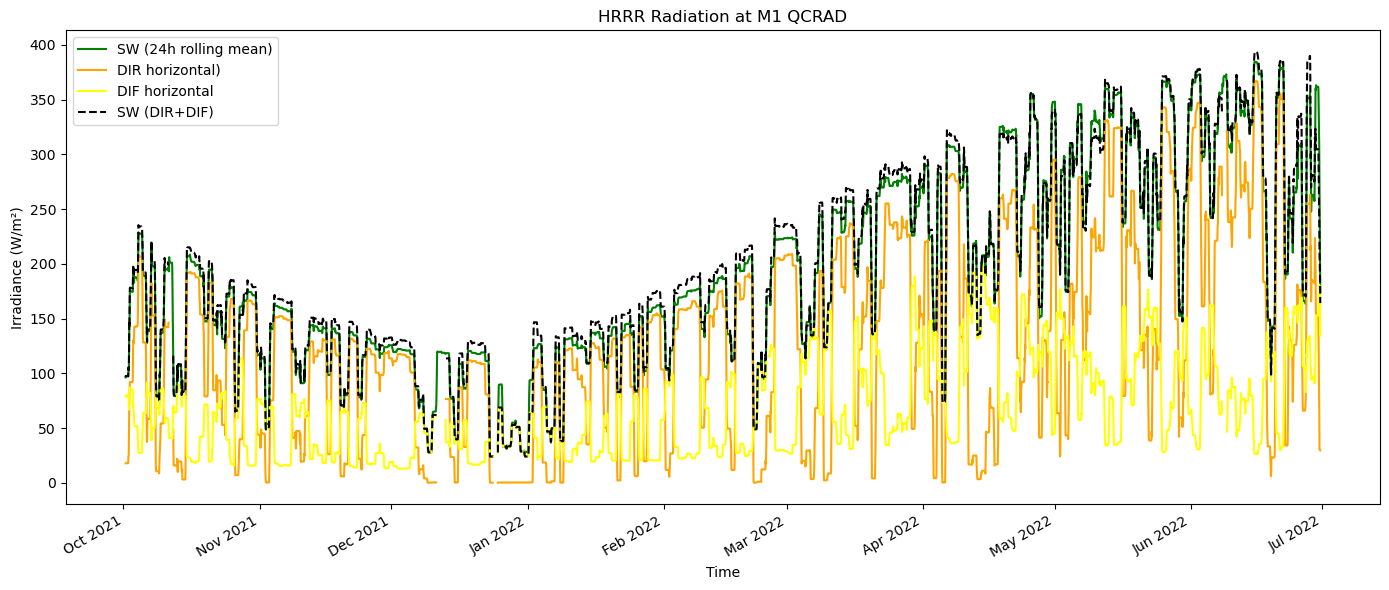

In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

win = 24

# Subset and load
subset_sw_rolling = subset_sw_hourly.rolling(time=win, center=True).mean()
subset_dif_rolling = subset_dif_hourly.rolling(time=win, center=True).mean()
subset_dir_rolling = sub_dirh_hourly.rolling(time=win, center=True).mean()
# subset_dif_rolling2 = sub_difh_hourly.rolling(time=win, center=True).mean()

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
# ax.plot(subset_sw_hourly.time, subset_sw_hourly, label='SW (raw)', color='lightgray', alpha=0.5)
ax.plot(subset_sw_rolling.time, subset_sw_rolling, label='SW (24h rolling mean)', color='green')
ax.plot(subset_dir_rolling.time, subset_dir_rolling, label='DIR horizontal)', color='orange')
ax.plot(subset_dif_rolling.time, subset_dif_rolling, label='DIF horizontal', color='yellow')
# ax.plot(subset_dif_rolling2.time, subset_dif_rolling2, label='DIF horizontal', color='yellow', linestyle="--")
ax.plot(subset_dif_rolling.time, subset_dif_rolling+subset_dir_rolling, label='SW (DIR+DIF)', color='black', linestyle="--")
# ax.plot(subset_dif_rolling2.time, subset_dif_rolling2+subset_dir_rolling, label='SW2 (DIR+DIF)', color='grey', linestyle="--")

# Formatting
ax.set_title('HRRR Radiation at M1 QCRAD')
ax.set_xlabel('Time')
ax.set_ylabel('Irradiance (W/m²)')
ax.legend()
# ax.grid(True)

# Better x-axis formatting
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate()

plt.tight_layout()
plt.show()
# svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/isnobal-2025-v01/"
# plt.savefig(svpth + 'm1_qcrad_sw_components.png', dpi=300, bbox_inches='tight')

In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

win = 24

# Rolling means
subset_sw_rolling = subset_sw_hourly.rolling(time=win, center=True).mean()
subset_sw_rolling_sail = subset_sw_hourly_sail.rolling(time=win, center=True).mean()

subset_dif_rolling = subset_dif_hourly.rolling(time=win, center=True).mean()
subset_dir_rolling = sub_dirh_hourly.rolling(time=win, center=True).mean()
subset_dif_rolling2 = sub_difh_hourly.rolling(time=win, center=True).mean()

subset_best_rolling = subset_best_hourly.rolling(time=win, center=True).mean()

# Set up 2-row subplot
fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, figsize=(16, 10), sharex=True)

# ---- Plot 1 ----
ax1.plot(subset_sw_rolling.time, subset_sw_rolling, label='SW (24h rolling mean)', color='green')
# ax1.plot(subset_sw_rolling_sail.time, subset_sw_rolling_sail, label='SW (24h rolling mean)', color='red')
ax1.plot(subset_dir_rolling.time, subset_dir_rolling, label='DIR horizontal', color='orange')
ax1.plot(subset_dif_rolling.time, subset_dif_rolling, label='DIF horizontal', color='yellow')
ax1.plot(subset_dif_rolling.time, subset_dif_rolling + subset_dir_rolling, label='SW (DIR+DIF)', color='black', linestyle='--')

ax1.set_title('HRRR Radiation at M1 QCRAD – Rolling Means')
ax1.set_ylabel('Irradiance (W/m²)')
ax1.legend()
# ax1.grid(True)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator())

# ---- Plot 2 ----
ax2.plot(subset_sw_rolling.time, subset_sw_rolling, label='SW (24h rolling mean)', color='green')
ax2.plot(subset_dir_rolling.time, subset_dir_rolling, label='DIR horizontal', color='orange')
ax2.plot(subset_dif_rolling2.time, subset_dif_rolling2, label='DIF horizontal (alternate)', color='yellow', linestyle="--")
ax2.plot(subset_dif_rolling2.time, subset_dif_rolling2 + subset_dir_rolling, label='SW2 (DIR+DIF)', color='black', linestyle="--")

ax2.set_title('Alternate DIF Estimate Comparison')
ax2.set_xlabel('Time')
ax2.set_ylabel('Irradiance (W/m²)')
ax2.legend()
# ax2.grid(True)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator())

# ---- Plot 3 ----
ax3.plot(subset_sw_rolling.time, subset_sw_rolling, label='SW (24h rolling mean)', color='green')
ax3.plot(subset_dir_rolling.time, subset_dir_rolling, label='DIR horizontal', color='orange')
ax3.plot(subset_dif_rolling.time, subset_dif_rolling, label='DIF horizontal', color='yellow')
ax3.plot(subset_best_rolling.time, subset_best_rolling, label='SW (BEST)', color='black', linestyle='--')

ax3.set_title('BEST QCRAD M1 QCRAD – Rolling Means')
ax3.set_ylabel('Irradiance (W/m²)')
ax3.legend()
# ax1.grid(True)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax3.xaxis.set_major_locator(mdates.MonthLocator())

# Plot 4
ax4.plot(subset_sw_rolling.time, subset_sw_rolling, label='SW QCRAD', color='green')
ax4.plot(subset_sw_rolling_sail.time, subset_sw_rolling_sail, label='SW SAIL', color='red', linestyle='--')
ax4.plot(subset_best_rolling.time, subset_best_rolling, label='SW (BEST QCRAD)', color='black', linestyle='--')

ax4.set_title('M1 SAIL VS QCRAD – Rolling Means')
ax4.set_ylabel('Irradiance (W/m²)')
ax4.legend()
# ax1.grid(True)
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax4.xaxis.set_major_locator(mdates.MonthLocator())

# Final formatting
fig.autofmt_xdate()
plt.tight_layout()
plt.show()
# svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/isnobal-2025-v01/"
# plt.savefig(svpth + 'm1_qcrad_sw_components_compare.png', dpi=300, bbox_inches='tight')

NameError: name 'subset_sw_hourly_sail' is not defined

In [32]:
sw2_hourly = (subset_dif_hourly + subset_dir_hourly)
np.array_equal(subset_sw_hourly.time, sw2_hourly.time)

True

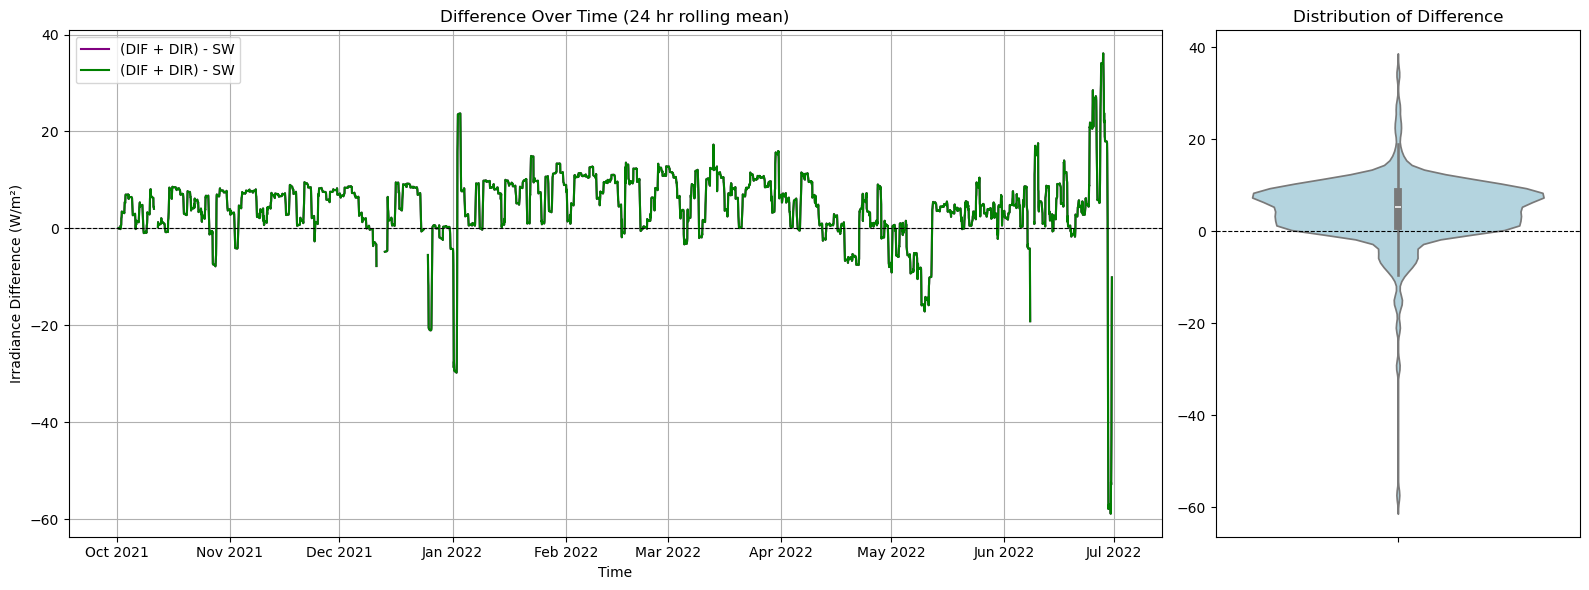

In [28]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd

# 1. Compute the difference (DIR + DIF - SW)
sw_diff = (subset_dif_rolling + subset_dir_rolling) - subset_sw_rolling
sw_diff2 = subset_best_rolling - subset_sw_rolling

# 2. Set up 1-row, 2-column figure
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(16, 6), gridspec_kw={'width_ratios': [3, 1]})

# ---- Left panel: Time series ----
ax1.plot(sw_diff.time, sw_diff, label='(DIF + DIR) - SW', color='purple')
# ax1.plot(sw_diff2.time, sw_diff, label='(DIF + DIR) - SW', color='green')
ax1.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax1.set_title("Difference Over Time (24 hr rolling mean)")
ax1.set_ylabel("Irradiance Difference (W/m²)")
ax1.set_xlabel("Time")
ax1.legend()
ax1.grid(True)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator())

# ---- Right panel: Violin plot ----
# Convert to Pandas for Seaborn
sw_diff_df = sw_diff.to_dataframe(name="diff").dropna()

sns.violinplot(y="diff", data=sw_diff_df, ax=ax2, color="lightblue", inner="box")
ax2.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax2.set_title("Distribution of Difference")
ax2.set_ylabel("")

# Tight layout and show
plt.tight_layout()
plt.show()
# svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/isnobal-2025-v01/"
# plt.savefig(svpth + 'm1_qcrad_sw_diff.png', dpi=300, bbox_inches='tight')

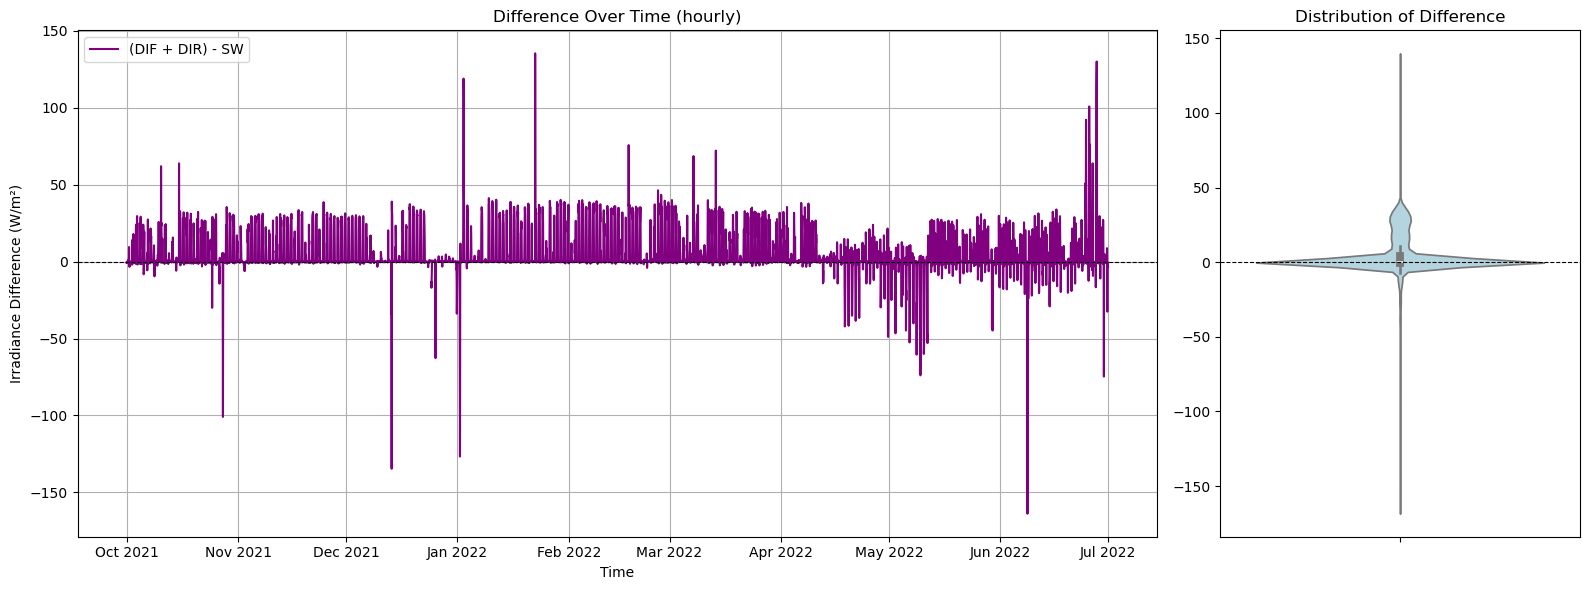

In [29]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd

# 1. Compute the difference (DIR + DIF - SW)
sw_diff = (subset_dif_hourly + subset_dir_hourly) - subset_sw_hourly
sw_diff = subset_best_hourly - subset_sw_hourly

# 2. Set up 1-row, 2-column figure
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(16, 6), gridspec_kw={'width_ratios': [3, 1]})

# ---- Left panel: Time series ----
ax1.plot(sw_diff.time, sw_diff, label='(DIF + DIR) - SW', color='purple')
ax1.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax1.set_title("Difference Over Time (hourly)")
ax1.set_ylabel("Irradiance Difference (W/m²)")
ax1.set_xlabel("Time")
ax1.legend()
ax1.grid(True)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator())

# ---- Right panel: Violin plot ----
# Convert to Pandas for Seaborn
sw_diff_df = sw_diff.to_dataframe(name="diff").dropna()

sns.violinplot(y="diff", data=sw_diff_df, ax=ax2, color="lightblue", inner="box")
ax2.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax2.set_title("Distribution of Difference")
ax2.set_ylabel("")

# Tight layout and show
plt.tight_layout()
plt.show()
# svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/isnobal-2025-v01/"
# plt.savefig(svpth + 'm1_qcrad_sw_diff_hr.png', dpi=300, bbox_inches='tight')

In [ ]:
# SHOW COMPARISON WITH MODELED DATA!
# WRF terrain configurations - read model

In [34]:
strt_time, end_time = "2022-03-01", "2022-03-07"


In [ ]:
strt_time, end_time = "2022-03-01", "2022-03-07"

sw_hourly = m1_qcrad['down_short_hemisp'].sel(time=slice(strt_time, end_time)).resample(time='1h').mean().load()
dif_hourly = m1_qcrad['down_short_diffuse_hemisp'].sel(time=slice(strt_time, end_time)).resample(time='1h').mean().load()
dir_hourly = m1_qcrad['short_direct_normal'].sel(time=slice(strt_time, end_time)).resample(time='1h').mean().load()
# short dir normal - adjust for zenith angle...
zenith_hourly = m1_qcrad['zenith'].sel(time=slice(strt_time, end_time)).resample(time='1h').mean().load()

# MODEL COMPARISON

In [7]:
# # Open the NetCDF file
# daysos = xr.open_dataset(sos_single)
# print(daysos)
# print(list(ds.data_vars))

In [41]:
# focus on IRWIN
SHARED_STORE = PurePath('/uufs/chpc.utah.edu/common/home/skiles-group1')
DATA_DIR = SHARED_STORE.joinpath('jmeyer')
SNOTEL_DIR = DATA_DIR.joinpath( 'Snotel')
from pathlib import Path, PurePath
snotel_sites = SnotelLocations()
snotel_sites.load_from_json(SNOTEL_DIR / 'site-locations/snotel_sites.json')
snotel_sites.Irwin

SnotelSite(name='Irwin', lon=[317131], lat=[4306375])

In [35]:
from dask.distributed import Client

# Optional: start Dask client to monitor computation
client = Client()

# file_pattern = '/uufs/chpc.utah.edu/common/home/u1037042/olson/snow-data/hrrr_toposplit/toposplit_*.nc'
file_pattern = '/uufs/chpc.utah.edu/common/home/u1037042/olson/snow-data/hrrr_toposplit_2022/toposplit_*.nc'

# file_pattern = f"{SHARED_STORE_RUN}/erw_spires_dsw3_dlwrf/{water_year}/erw_50m/run*/net_solar.nc"

HRRR_solar = xr.open_mfdataset(
    file_pattern,
    combine='by_coords',
    parallel=True, chunks={'time': 24}, # 'y' :10, 'x': 10},
)

/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 45301 instead
  warnings.warn(
2025-06-25 11:37:28,206 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:33725' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('getitem-c155da26d5a3faf7116786cb674e3978', 284), ('getitem-c155da26d5a3faf7116786cb674e3978', 43), ('getitem-c155da26d5a3faf7116786cb674e3978', 223), ('getitem-c155da26d5a3faf7116786cb674e3978', 293), ('getitem-c155da26d5a3faf7116786cb674e3978', 52), 'original-open_dataset-dsw3-0ab2bc73a7cc07a2ddf1b27d00029e76', ('getitem-c155da26d5a3faf7116786cb674e3978', 61), ('getitem-c155da26d5a3faf7116786cb674e3978', 3), ('getitem-c155da26d5a3faf7116786cb674e3978', 9), ('getitem-c155da26d5a3faf7116786cb674e3978', 67), ('getitem-c155

In [ ]:
HRRR_solar

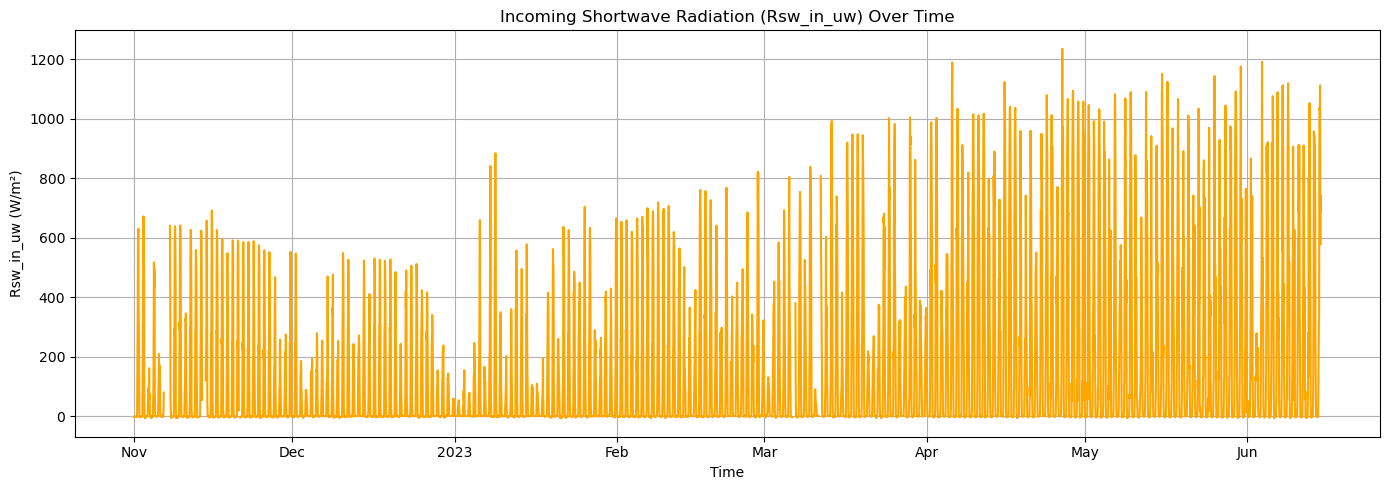

In [5]:
# Plot the variable over time
# plt.figure(figsize=(14, 5))
# ds['Rsw_in_uw'].plot(x='time', color='orange')

# # Formatting
# plt.title('Incoming Shortwave Radiation (Rsw_in_uw) Over Time')
# plt.xlabel('Time')
# plt.ylabel('Rsw_in_uw (W/m²)')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [ ]:
sos_coords = {"lat": ds.latitude_uw.isel(time=0).values.item(), "lon": ds.latitude_uw.isel(time=0).values.item()}

print(sos_coords)

In [37]:
import geopandas as gpd
from shapely.geometry import Point

def convert_to_utm(coords):
    """
    Convert coordinates from WGS84 (lat/lon) to UTM Zone 13N (EPSG:26913)
    
    :param coords: Dictionary with 'lat' and 'lon' keys
    :return: Dictionary with 'utm_x' and 'utm_y' keys for UTM coordinates
    """
    # Create a GeoDataFrame with the coordinates
    gdf = gpd.GeoDataFrame(
        {'geometry': [Point(coords['lon'], coords['lat'])]}, 
        crs="EPSG:4326"  # WGS84 (Lat/Lon)
    )

    # Convert to UTM Zone 13N
    gdf_utm = gdf.to_crs(epsg=26913)

    # Extract the UTM X and Y coordinates
    utm_x, utm_y = gdf_utm.geometry.x[0], gdf_utm.geometry.y[0]
    
    # Return the result as a dictionary
    return {'utm_x': utm_x, 'utm_y': utm_y}

# Define m1_coords and s3_coords (example data)
m1_coords = {"lat": 38.95615768432617, "lon": -106.98785400390625}
s3_coords = {"lat": 39.750715, "lon": -104.998649}
sos_coords = {"lat": ds.latitude_uw.isel(time=0).values.item(), "lon": ds.latitude_uw.isel(time=0).values.item()}

# Convert both coordinates
m1_utm = convert_to_utm(m1_coords)
s3_utm = convert_to_utm(s3_coords)
sos_utm = convert_to_utm(sos_coords)

# Combine the results into a final object
final_utm_coords = {
    'm1_coords_utm': m1_utm, #ARM QCRAD also at M1 site! (CHECK)
    's3_coords_utm': s3_utm,
    'sos_coords_utm': sos_utm
}

# Print the result
print(final_utm_coords)


{'m1_coords_utm': {'utm_x': np.float64(327754.55108678306), 'utm_y': np.float64(4313790.299013529)}, 's3_coords_utm': {'utm_x': np.float64(500115.76987025986), 'utm_y': np.float64(4400089.488481599)}, 'sos_coords_utm': {'utm_x': np.float64(3657472.2020449075), 'utm_y': np.float64(15011385.744460348)}}


In [48]:
final_utm_coords['m1_coords_utm']['utm_x']

print(final_utm_coords['sos_coords_utm']['utm_y'])
print(final_utm_coords['s3_coords_utm']['utm_y'])

15011385.744460348
4400089.488481599


In [49]:
irwin_ghi = HRRR_solar.ghi.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').squeeze(['x', 'y']).compute()
irwin_dsw1 = HRRR_solar.dsw1.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').squeeze(['x', 'y']).compute()
irwin_dsw30 = HRRR_solar.dsw3.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').squeeze(['x', 'y']).compute()
irwin_dsw3 = HRRR_solar.dsw3h.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').squeeze(['x', 'y']).compute()
irwin_k = HRRR_solar.k.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').squeeze(['x', 'y']).compute()

m1_ghi = HRRR_solar.ghi.sel(x=final_utm_coords['m1_coords_utm']['utm_x'], y=final_utm_coords['m1_coords_utm']['utm_y'], method='nearest').squeeze().compute()
m1_dsw1 = HRRR_solar.dsw1.sel(x=final_utm_coords['m1_coords_utm']['utm_x'], y=final_utm_coords['m1_coords_utm']['utm_y'], method='nearest').squeeze().compute()
m1_dsw30 = HRRR_solar.dsw3.sel(x=final_utm_coords['m1_coords_utm']['utm_x'], y=final_utm_coords['m1_coords_utm']['utm_y'], method='nearest').squeeze().compute()
m1_dsw3 = HRRR_solar.dsw3h.sel(x=final_utm_coords['m1_coords_utm']['utm_x'], y=final_utm_coords['m1_coords_utm']['utm_y'], method='nearest').squeeze().compute()
m1_k = HRRR_solar.k.sel(x=final_utm_coords['m1_coords_utm']['utm_x'], y=final_utm_coords['m1_coords_utm']['utm_y'], method='nearest').squeeze().compute()

s3_ghi = HRRR_solar.ghi.sel(x=final_utm_coords['s3_coords_utm']['utm_x'], y=final_utm_coords['s3_coords_utm']['utm_y'], method='nearest').squeeze().compute()
s3_dsw1 = HRRR_solar.dsw1.sel(x=final_utm_coords['s3_coords_utm']['utm_x'], y=final_utm_coords['s3_coords_utm']['utm_y'], method='nearest').squeeze().compute()
s3_dsw30 = HRRR_solar.dsw3.sel(x=final_utm_coords['s3_coords_utm']['utm_x'], y=final_utm_coords['s3_coords_utm']['utm_y'], method='nearest').squeeze().compute()
s3_dsw3 = HRRR_solar.dsw3h.sel(x=final_utm_coords['s3_coords_utm']['utm_x'], y=final_utm_coords['s3_coords_utm']['utm_y'], method='nearest').squeeze().compute()
s3_k = HRRR_solar.k.sel(x=final_utm_coords['s3_coords_utm']['utm_x'], y=final_utm_coords['s3_coords_utm']['utm_y'], method='nearest').squeeze().compute()

sos_ghi = HRRR_solar.ghi.sel(x=final_utm_coords['sos_coords_utm']['utm_x'], y=final_utm_coords['sos_coords_utm']['utm_y'], method='nearest').squeeze().compute()
sos_dsw1 = HRRR_solar.dsw1.sel(x=final_utm_coords['sos_coords_utm']['utm_x'], y=final_utm_coords['sos_coords_utm']['utm_y'], method='nearest').squeeze().compute()
sos_dsw30 = HRRR_solar.dsw3.sel(x=final_utm_coords['sos_coords_utm']['utm_x'], y=final_utm_coords['sos_coords_utm']['utm_y'], method='nearest').squeeze().compute()
sos_dsw3 = HRRR_solar.dsw3h.sel(x=final_utm_coords['sos_coords_utm']['utm_x'], y=final_utm_coords['sos_coords_utm']['utm_y'], method='nearest').squeeze().compute()
sos_k = HRRR_solar.k.sel(x=final_utm_coords['sos_coords_utm']['utm_x'], y=final_utm_coords['sos_coords_utm']['utm_y'], method='nearest').squeeze().compute()

# m1_ghi = HRRR_solar.ghi.sel(x=m1_utm_x, y=m1_utm_y, method='nearest').squeeze().compute()
# m1_dsw1 = HRRR_solar.dsw1.sel(x=m1_utm_x, y=m1_utm_y, method='nearest').squeeze().compute()
# m1_dsw30 = HRRR_solar.dsw3.sel(x=m1_utm_x, y=m1_utm_y, method='nearest').squeeze().compute()
# m1_dsw3 = HRRR_solar.dsw3h.sel(x=m1_utm_x, y=m1_utm_y, method='nearest').squeeze().compute()
# m1_k = HRRR_solar.k.sel(x=m1_utm_x, y=m1_utm_y, method='nearest').squeeze().compute()

KeyboardInterrupt: 

In [50]:
irwin_ghi = HRRR_solar.ghi.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').squeeze(['x', 'y']).compute()
irwin_dsw1 = HRRR_solar.dsw1.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').squeeze(['x', 'y']).compute()
irwin_dsw30 = HRRR_solar.dsw3.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').squeeze(['x', 'y']).compute()
irwin_dsw3 = HRRR_solar.dsw3h.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').squeeze(['x', 'y']).compute()
irwin_k = HRRR_solar.k.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').squeeze(['x', 'y']).compute()


KeyboardInterrupt: 

In [ ]:
# Access the UTM coordinates for m1
m1_utm_x = final_utm_coords['m1_coords_utm']['utm_x']
m1_utm_y = final_utm_coords['m1_coords_utm']['utm_y']

# Access the UTM coordinates for s3
s3_utm_x = final_utm_coords['s3_coords_utm']['utm_x']
s3_utm_y = final_utm_coords['s3_coords_utm']['utm_y']

# Print the results
print("M1 UTM Coordinates:", m1_utm_x, m1_utm_y)
print("S3 UTM Coordinates:", s3_utm_x, s3_utm_y)

In [ ]:
m1_ghi = HRRR_solar.ghi.sel(x=m1_utm_x, y=m1_utm_y, method='nearest').squeeze().compute()
m1_dsw1 = HRRR_solar.dsw1.sel(x=m1_utm_x, y=m1_utm_y, method='nearest').squeeze().compute()
m1_dsw30 = HRRR_solar.dsw3.sel(x=m1_utm_x, y=m1_utm_y, method='nearest').squeeze().compute()
m1_dsw3 = HRRR_solar.dsw3h.sel(x=m1_utm_x, y=m1_utm_y, method='nearest').squeeze().compute()
m1_k = HRRR_solar.k.sel(x=m1_utm_x, y=m1_utm_y, method='nearest').squeeze().compute()

s3_ghi = HRRR_solar.ghi.sel(x=s3_utm_x, y=s3_utm_y, method='nearest').squeeze().compute()
s3_dsw1 = HRRR_solar.dsw1.sel(x=s3_utm_x, y=s3_utm_y, method='nearest').squeeze().compute()
s3_dsw30 = HRRR_solar.dsw3.sel(x=s3_utm_x, y=s3_utm_y, method='nearest').squeeze().compute()
s3_dsw3 = HRRR_solar.dsw3h.sel(x=s3_utm_x, y=s3_utm_y, method='nearest').squeeze().compute()
s3_k = HRRR_solar.k.sel(x=s3_utm_x, y=s3_utm_y, method='nearest').squeeze().compute()

In [ ]:
# observations
m1_sail
s3_sail
ds # SOS

In [ ]:
# model
m1_dsw3 # x2 M1 & QC
s3_dsw3
sos_dsw3
irwin_dsw3

In [ ]:
m1_sail

In [ ]:
# DONE for qc

# subset_sw_hourly = m1_qcrad['down_short_hemisp'].sel(time=slice("2021-10-01", "2022-06-30")).resample(time='1h').mean().load()

subset_sw_hourly_m1 = m1_sail['down_short_hemisp'].sel(time=slice("2021-10-01", "2022-06-30")).resample(time='1h').mean().load()

subset_sw_hourly_s3 = s3_sail['down_short_hemisp'].sel(time=slice("2021-10-01", "2022-06-30")).resample(time='1h').mean().load()

subset_sw_hourly_ds = ds['down_short_hemisp'].sel(time=slice("2021-10-01", "2022-06-30")).resample(time='1h').mean().load()


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

win = 24

# Rolling means
subset_sw_rolling = subset_sw_hourly.rolling(time=win, center=True).mean()
subset_sw_rolling_sail = subset_sw_hourly_sail.rolling(time=win, center=True).mean()

subset_dif_rolling = subset_dif_hourly.rolling(time=win, center=True).mean()
subset_dir_rolling = sub_dirh_hourly.rolling(time=win, center=True).mean()
subset_dif_rolling2 = sub_difh_hourly.rolling(time=win, center=True).mean()

subset_best_rolling = subset_best_hourly.rolling(time=win, center=True).mean()

# Set up 2-row subplot
fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, figsize=(16, 10), sharex=True)

# ---- M1 ----
ax1.plot(subset_sw_rolling.time, subset_sw_rolling, label='SW (24h rolling mean)', color='green')
# ax1.plot(subset_sw_rolling_sail.time, subset_sw_rolling_sail, label='SW (24h rolling mean)', color='red')
ax1.plot(subset_dir_rolling.time, subset_dir_rolling, label='DIR horizontal', color='orange')
ax1.plot(subset_dif_rolling.time, subset_dif_rolling, label='DIF horizontal', color='yellow')
ax1.plot(subset_dif_rolling.time, subset_dif_rolling + subset_dir_rolling, label='SW (DIR+DIF)', color='black', linestyle='--')

ax1.set_title('HRRR Radiation at M1 QCRAD – Rolling Means')
ax1.set_ylabel('Irradiance (W/m²)')
ax1.legend()
# ax1.grid(True)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator())

# ---- M1 QCRAD ----
ax2.plot(subset_sw_rolling.time, subset_sw_rolling, label='SW (24h rolling mean)', color='green')
ax2.plot(subset_dir_rolling.time, subset_dir_rolling, label='DIR horizontal', color='orange')
ax2.plot(subset_dif_rolling2.time, subset_dif_rolling2, label='DIF horizontal (alternate)', color='yellow', linestyle="--")
ax2.plot(subset_dif_rolling2.time, subset_dif_rolling2 + subset_dir_rolling, label='SW2 (DIR+DIF)', color='black', linestyle="--")

ax2.set_title('Alternate DIF Estimate Comparison')
ax2.set_xlabel('Time')
ax2.set_ylabel('Irradiance (W/m²)')
ax2.legend()
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator())

# ---- S3 ----
ax3.plot(subset_sw_rolling.time, subset_sw_rolling, label='SW (24h rolling mean)', color='green')
ax3.plot(subset_dir_rolling.time, subset_dir_rolling, label='DIR horizontal', color='orange')
ax3.plot(subset_dif_rolling.time, subset_dif_rolling, label='DIF horizontal', color='yellow')
ax3.plot(subset_best_rolling.time, subset_best_rolling, label='SW (BEST)', color='black', linestyle='--')

ax3.set_title('BEST QCRAD M1 QCRAD – Rolling Means')
ax3.set_ylabel('Irradiance (W/m²)')
ax3.legend()
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax3.xaxis.set_major_locator(mdates.MonthLocator())

# ---- SOS ----
ax4.plot(subset_sw_rolling.time, subset_sw_rolling, label='SW QCRAD', color='green')
ax4.plot(subset_sw_rolling_sail.time, subset_sw_rolling_sail, label='SW SAIL', color='red', linestyle='--')
ax4.plot(subset_best_rolling.time, subset_best_rolling, label='SW (BEST QCRAD)', color='black', linestyle='--')

ax4.set_title('M1 SAIL VS QCRAD – Rolling Means')
ax4.set_ylabel('Irradiance (W/m²)')
ax4.legend()
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax4.xaxis.set_major_locator(mdates.MonthLocator())

# Final formatting
fig.autofmt_xdate()
plt.tight_layout()
plt.show()
# svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/isnobal-2025-v01/"
# plt.savefig(svpth + 'm1_qcrad_sw_components_compare.png', dpi=300, bbox_inches='tight')